## Titanic Survival Analysis — EDA Summary

**Dataset:** 891 passengers | 12 features | Kaggle Titanic Dataset

---

## Key Findings

**Finding 1 — Gender was the strongest predictor**
74% of females survived vs only 19% of males.
Gender alone is the most powerful signal in this dataset.

**Finding 2 — Passenger class had major impact**
1st class: 63% survived | 2nd class: 47% | 3rd class: 24%
Wealth and class directly determined survival odds.

**Finding 3 — Small families survived best**
Passengers with FamilySize 2–3 had the highest survival rate.
Solo travellers and very large families did significantly worse.

**Finding 4 — Age had a visible but weak effect**
Children under 10 had noticeably higher survival rates.
Elderly passengers had lower survival rates.

**Finding 5 — Higher fare correlates with survival**
But this is largely because fare reflects class — not fare itself.

---

## Tools Used
Python | Pandas | NumPy | Matplotlib | Seaborn


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df = df.drop("Cabin", axis=1,errors = "ignore")
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [7]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Female passengers had a significantly higher survival rate than male passengers.

In [8]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

<Axes: xlabel='Sex', ylabel='count'>

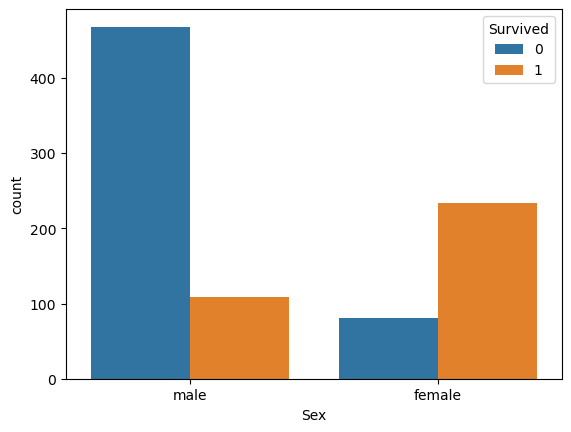

In [9]:
sns.countplot(x="Sex", hue="Survived", data=df)

## First class passengers survived more frequently.

In [10]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

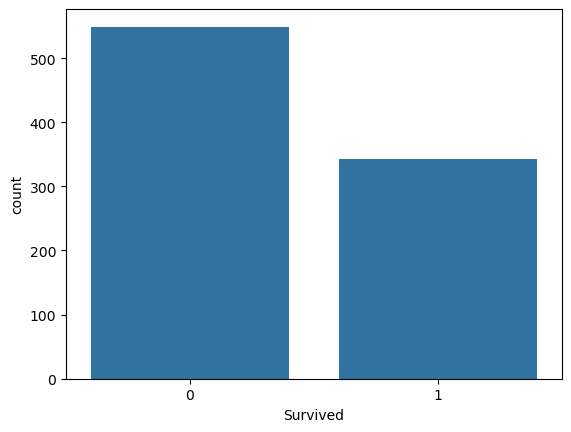

In [11]:
sns.countplot(x="Survived", data=df)

In [12]:
df.groupby("Pclass")["Survived"].mean()




Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

<Axes: xlabel='Pclass', ylabel='count'>

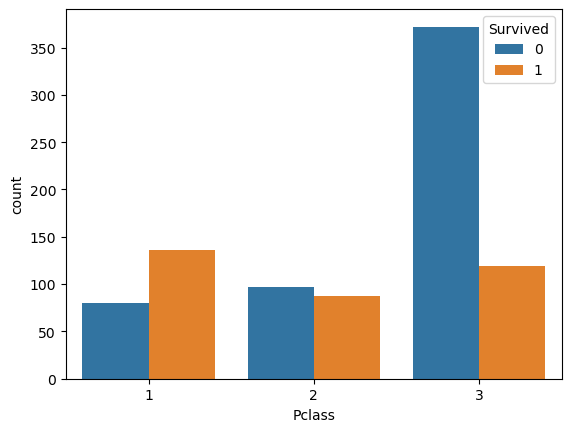

In [13]:
sns.countplot(x="Pclass", hue="Survived", data=df)

## Age distribution suggests younger passengers had slightly higher survival.

<Axes: >

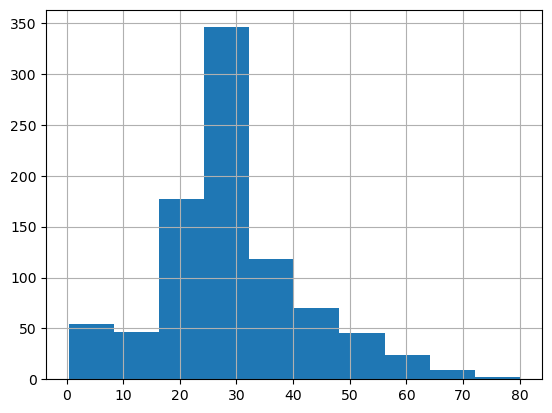

In [14]:
df["Age"].hist()

<Axes: xlabel='Survived', ylabel='Fare'>

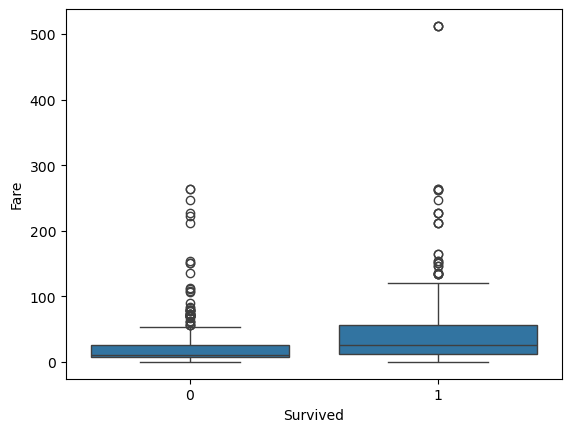

In [15]:
sns.boxplot(x="Survived", y="Fare", data=df)

In [16]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

## Age vs survived

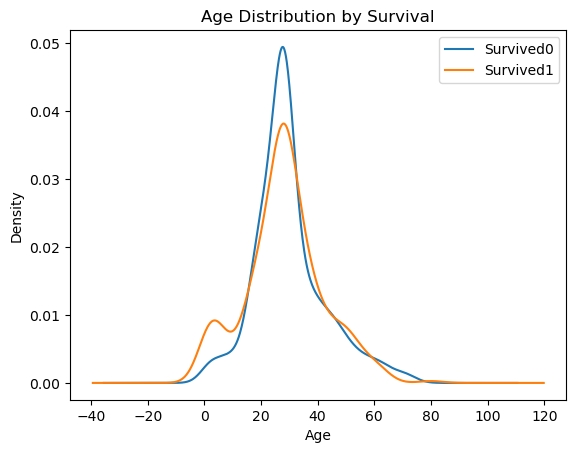

In [17]:
for Survived in [0,1]:
    df[df["Survived"] == Survived]["Age"].plot(kind="kde" , label = f"Survived{Survived}")

plt.legend()
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.show()

## Family size VS survival rate

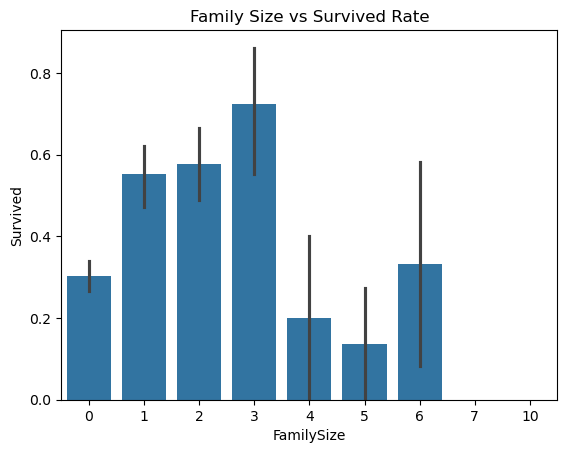

In [18]:
sns.barplot(x="FamilySize", y= "Survived" , data = df)
plt.title("Family Size vs Survived Rate")
plt.show()

## Embarked vs Survival Rate

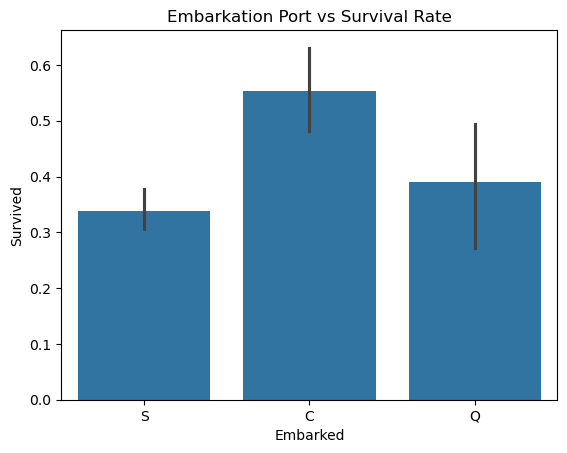

In [19]:
sns.barplot(x="Embarked" , y = "Survived" , data = df)
plt.title( "Embarkation Port vs Survival Rate")
plt.show()

## Pclass vs Fare

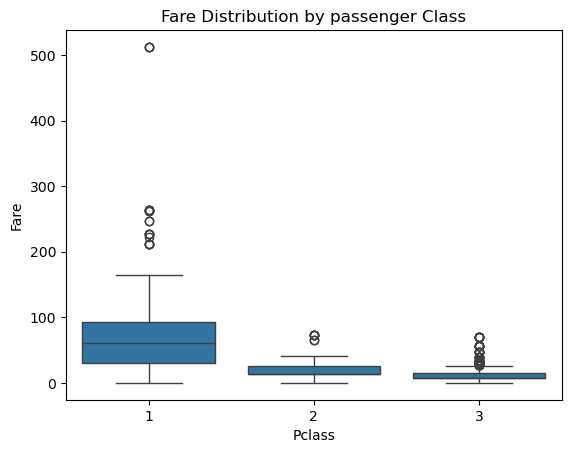

In [20]:
sns.boxplot ( x="Pclass" ,  y = "Fare" , data = df)
plt.title("Fare Distribution by passenger Class")
plt.show()

## Sex + Pclass vs Survival Rate

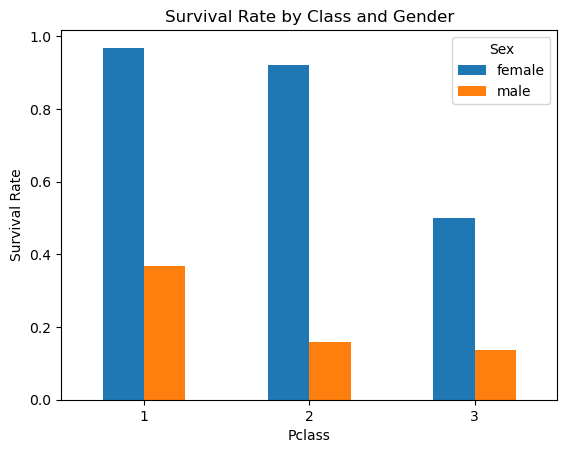

In [21]:
Survival_rate = df.groupby(["Pclass","Sex"])["Survived"].mean().unstack()
Survival_rate.plot(kind="bar")
plt.title("Survival Rate by Class and Gender")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()



## Correlation Heatmap


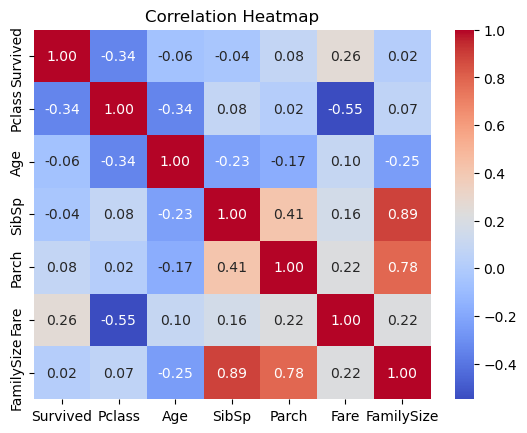

In [22]:
numeric_df = df[["Survived", "Pclass", "Age", 
                  "SibSp", "Parch", "Fare", "FamilySize"]]
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Age vs Survived (boxplot)


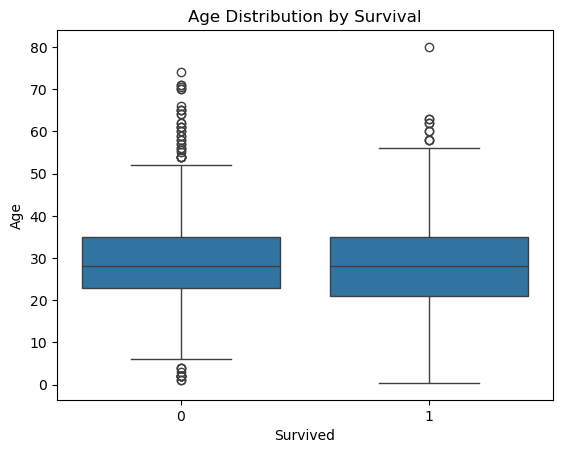

In [23]:
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age Distribution by Survival")
plt.show()

## Survival Count by Pclass and Sex (countplot)


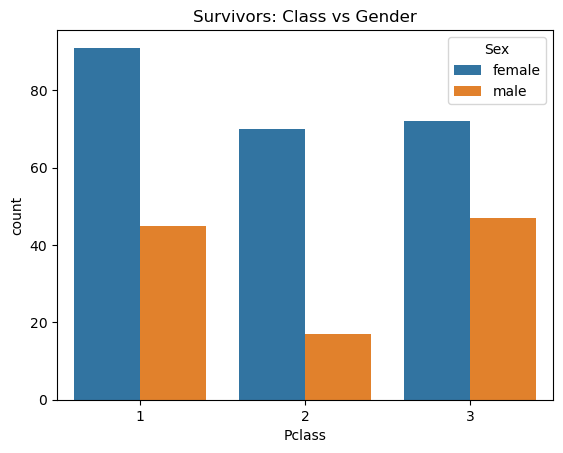

In [24]:
sns.countplot(x="Pclass", hue="Sex", data=df[df["Survived"] == 1])
plt.title("Survivors: Class vs Gender")
plt.show()
